# Cross-Sectional ML Model - ADNI Demographic + Clinical Assessments

In [1]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
# Load adni_all.csv file as all
all = pd.read_csv('/Users/hieubui/Documents/Thesis 2027/data/adni_all.csv')
all.head()

,subject_id,visit,PTGENDER,entry_age,entry_research_group,PTRACCAT,PTETHCAT,PTEDUCAT,GENOTYPE,CDRSB,...,LIMMTOTAL,VSWEIGHT,VSHEIGHT,VSBPSYS,VSBPDIA,GDTOTAL,CATANIMSC,FAQTOTAL,NPISCORE,TOTAL13
0,002_S_0295,bl,1.0,84.84,CN,NaN,NaN,NaN,3/4,NaN,...,NaN,75.0,NaN,148.0,66.0,NaN,13.0,0.0,0.0,4.00
1,002_S_0295,m06,1.0,84.84,CN,NaN,NaN,NaN,3/4,0.0,...,NaN,74.1,NaN,135.0,66.0,NaN,19.0,0.0,0.0,6.33
2,002_S_0295,m12,1.0,84.84,CN,NaN,NaN,NaN,3/4,0.0,...,18.0,72.6,NaN,126.0,58.0,0.0,22.0,0.0,0.0,5.67
3,002_S_0295,m18,1.0,84.84,CN,NaN,NaN,NaN,3/4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,002_S_0295,m24,1.0,84.84,CN,NaN,NaN,NaN,3/4,0.0,...,12.0,162.6,NaN,136.0,62.0,0.0,16.0,0.0,0.0,5.67


In [28]:
print(all.info())
print(all.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24132 entries, 0 to 24131
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   subject_id            24132 non-null  object 
 1   visit                 24132 non-null  object 
 2   PTGENDER              24082 non-null  float64
 3   entry_age             24080 non-null  float64
 4   entry_research_group  23253 non-null  object 
 5   PTRACCAT              5392 non-null   object 
 6   PTETHCAT              5359 non-null   float64
 7   PTEDUCAT              5386 non-null   float64
 8   GENOTYPE              22408 non-null  object 
 9   CDRSB                 14156 non-null  float64
 10  TRAASCOR              12510 non-null  float64
 11  TRABSCOR              12154 non-null  float64
 12  LDELTOTAL             12101 non-null  float64
 13  AVDEL30MIN            12513 non-null  float64
 14  AVDELTOT              12486 non-null  float64
 15  MMSCORE            

In [29]:
# Count missing values in each column
missing_values = all.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
subject_id                  0
visit                       0
PTGENDER                   50
entry_age                  52
entry_research_group      879
PTRACCAT                18740
PTETHCAT                18773
PTEDUCAT                18746
GENOTYPE                 1724
CDRSB                    9976
TRAASCOR                11622
TRABSCOR                11978
LDELTOTAL               12031
AVDEL30MIN              11619
AVDELTOT                11646
MMSCORE                 10076
LIMMTOTAL               11977
VSWEIGHT                 7562
VSHEIGHT                19338
VSBPSYS                  7500
VSBPDIA                  7501
GDTOTAL                 10983
CATANIMSC               11521
FAQTOTAL                11149
NPISCORE                16607
TOTAL13                 11640
dtype: int64


In [30]:
# Show missing values percentage in each column
missing_percentage = (missing_values / len(all)) * 100
print("Missing values percentage in each column:")
print(missing_percentage)

Missing values percentage in each column:
subject_id               0.000000
visit                    0.000000
PTGENDER                 0.207194
entry_age                0.215482
entry_research_group     3.642466
PTRACCAT                77.656224
PTETHCAT                77.792972
PTEDUCAT                77.681087
GENOTYPE                 7.144041
CDRSB                   41.339301
TRAASCOR                48.160119
TRABSCOR                49.635339
LDELTOTAL               49.854964
AVDEL30MIN              48.147688
AVDELTOT                48.259572
MMSCORE                 41.753688
LIMMTOTAL               49.631195
VSWEIGHT                31.335985
VSHEIGHT                80.134262
VSBPSYS                 31.079065
VSBPDIA                 31.083209
GDTOTAL                 45.512183
CATANIMSC               47.741588
FAQTOTAL                46.200066
NPISCORE                68.817338
TOTAL13                 48.234709
dtype: float64


In [31]:
# Count values in entry_research_group column
all['entry_research_group'].value_counts()

entry_research_group
MCI    11425
CN      9134
AD      2694
Name: count, dtype: int64

In [32]:
# Count doublicate rows in the dataset
duplicate_rows = all[all.duplicated()]
print("Number of duplicate rows:", len(duplicate_rows))

Number of duplicate rows: 0


In [34]:
# Select features and target variable
features = all.drop(columns=['subject_id', 'entry_research_group', 'visit', 'PTRACCAT', 
                             'PTETHCAT', 'PTEDUCAT', 'AVDEL30MIN', 'AVDELTOT', 'LIMMTOTAL',
                             'VSWEIGHT', 'VSHEIGHT','VSBPSYS', 'VSBPDIA','NPISCORE', 'GENOTYPE'])
target = all['entry_research_group']

print("Features columns:")
print(features.columns)
print("Target variable:")
print(target.value_counts())

Features columns:
Index(['PTGENDER', 'entry_age', 'CDRSB', 'TRAASCOR', 'TRABSCOR', 'LDELTOTAL',
       'MMSCORE', 'GDTOTAL', 'CATANIMSC', 'FAQTOTAL', 'TOTAL13'],
      dtype='object')
Target variable:
entry_research_group
MCI    11425
CN      9134
AD      2694
Name: count, dtype: int64


Text(0, 0.5, 'Count')

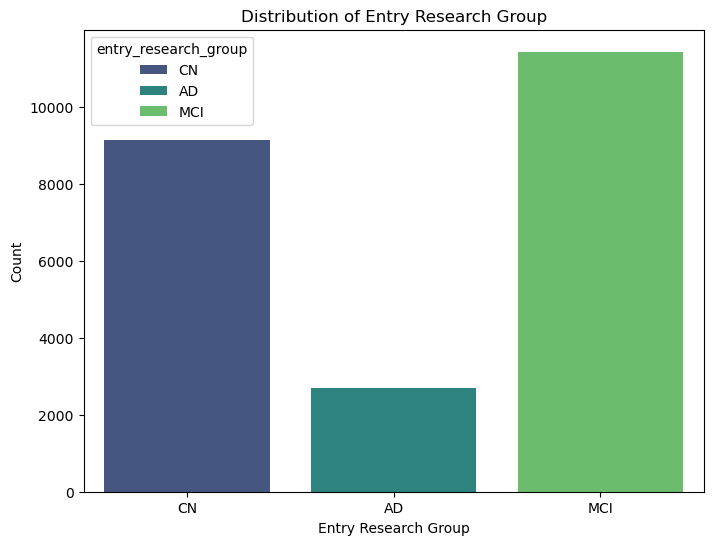

In [35]:
# Visualize the distribution of the target variable
plt.figure(figsize=(8, 6))
sns.countplot(x=target, hue=target, palette='viridis')
plt.title('Distribution of Entry Research Group')
plt.xlabel('Entry Research Group')
plt.ylabel('Count')

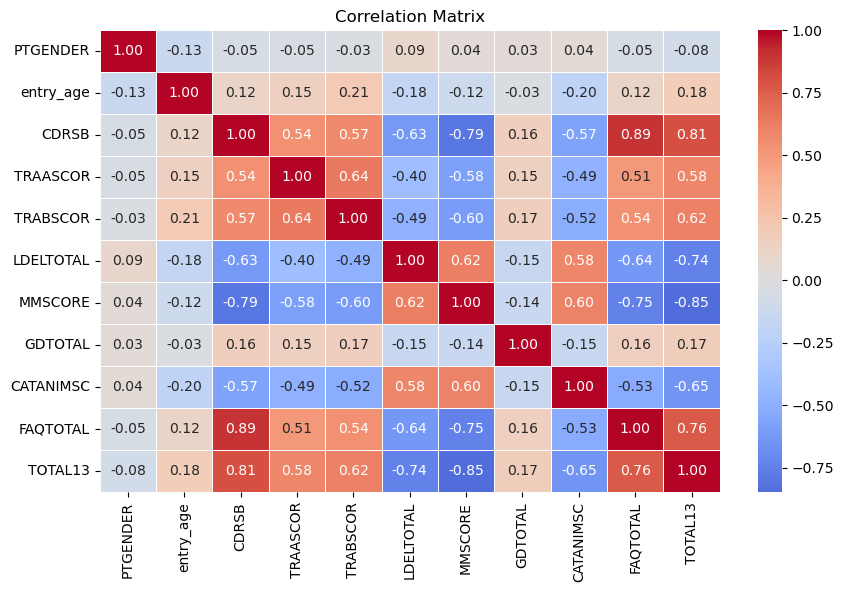

In [42]:
# Correlation matrix
correlation_matrix = features.corr()

# Visualize the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5, fmt=".2f")
plt.title('Correlation Matrix')
plt.show()